# 03 — Exploratory Data Analysis
Full EDA across 10 categories. Figures saved to `reports/figures/`.

In [15]:
# CELL 1: IMPORTS
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
from scipy import signal, stats
from scipy.cluster import hierarchy
from scipy.spatial.distance import pdist, squareform
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')

SAVE_DIR = os.path.join('..', 'data', 'processed')
FIG_DIR  = os.path.join('..', 'reports', 'figures')
LEAD_NAMES = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']
COLORS = ['#6366f1','#0ea5e9','#10b981','#f59e0b','#ef4444']
FS = 100
print("Imports OK ✅")

Imports OK ✅


In [16]:
# CELL 2: LOAD DATA
X       = np.load(os.path.join(SAVE_DIR, 'X_clean.npy'))
y       = np.load(os.path.join(SAVE_DIR, 'y.npy'))
df      = pd.read_pickle(os.path.join(SAVE_DIR, 'metadata.pkl'))
with open(os.path.join(SAVE_DIR, 'classes.pkl'), 'rb') as f:
    CLASSES = pickle.load(f)
batch_df = df.iloc[:len(X)].copy()

for cat in ['clinical','morphology','frequency','leads','ml_space','quality','dynamics']:
    os.makedirs(os.path.join(FIG_DIR, cat), exist_ok=True)

print(f"X={X.shape}  y={y.shape}  classes={CLASSES}")

X=(200, 1000, 12)  y=(200, 5)  classes=['CD', 'HYP', 'MI', 'NORM', 'STTC']


## Section 1 — Clinical Insight

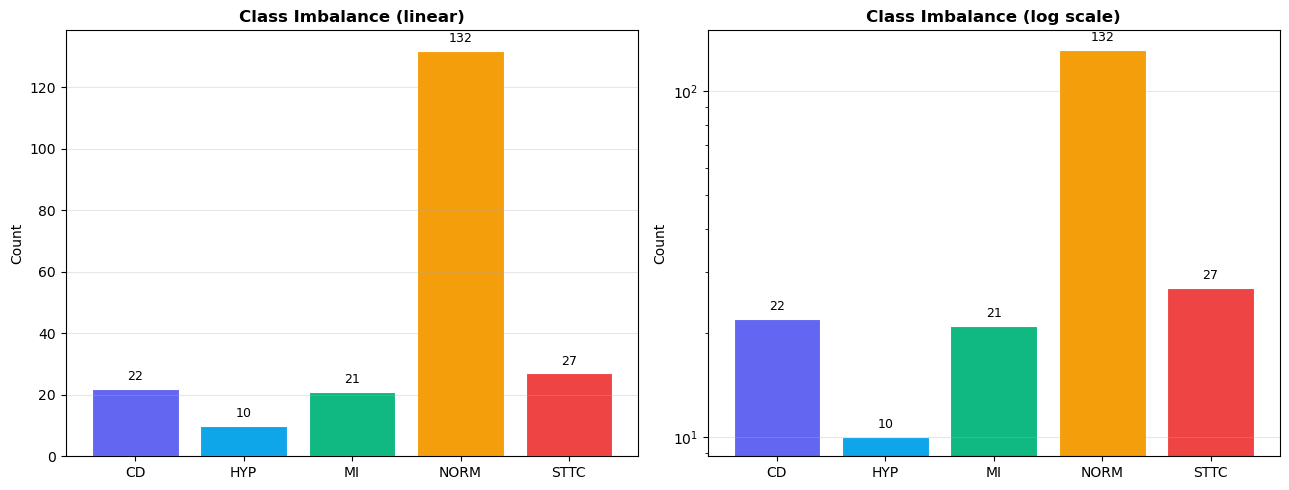

In [17]:
# CELL 3: 1.1 Class Imbalance — Bar + Log Scale
counts = y.sum(axis=0)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, yscale, title in zip(axes, ['linear','log'],
    ['Class Imbalance (linear)','Class Imbalance (log scale)']):
    bars = ax.bar(CLASSES, counts, color=COLORS, edgecolor='white', linewidth=0.8)
    ax.bar_label(bars, fmt='%d', padding=4, fontsize=9)
    ax.set_yscale(yscale)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'clinical','1_1_class_imbalance.png'), dpi=150, bbox_inches='tight')
plt.show()

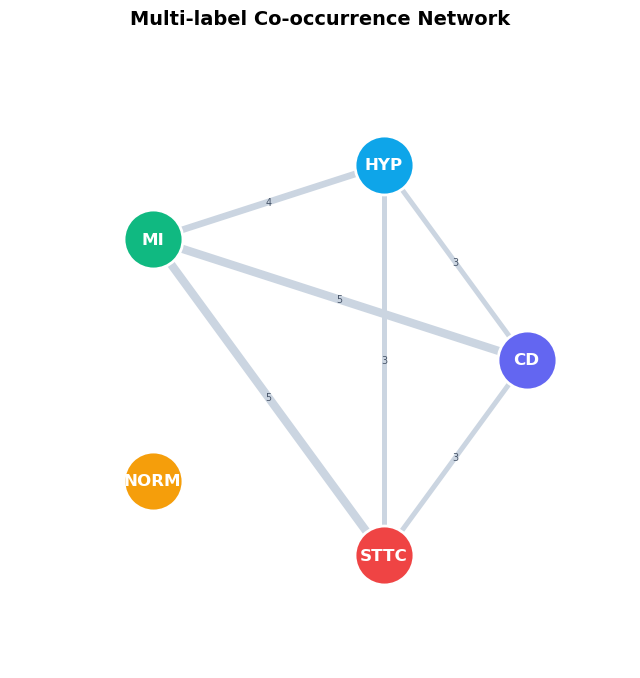

In [18]:
# CELL 4: 1.2 Multi-label Co-occurrence Network
co = y.T @ y   # (5,5) co-occurrence matrix
np.fill_diagonal(co, 0)

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5); ax.axis('off')
theta = np.linspace(0, 2*np.pi, len(CLASSES), endpoint=False)
pos   = {c: (np.cos(t), np.sin(t)) for c, t in zip(CLASSES, theta)}

# draw edges
max_co = co.max() or 1
for i in range(len(CLASSES)):
    for j in range(i+1, len(CLASSES)):
        if co[i,j] > 0:
            lw = 6 * co[i,j] / max_co
            x  = [pos[CLASSES[i]][0], pos[CLASSES[j]][0]]
            y_ = [pos[CLASSES[i]][1], pos[CLASSES[j]][1]]
            ax.plot(x, y_, color='#cbd5e1', linewidth=lw, zorder=1)
            mid = ((x[0]+x[1])/2, (y_[0]+y_[1])/2)
            ax.text(mid[0], mid[1], str(int(co[i,j])), fontsize=7,
                    ha='center', va='center', color='#475569')
# draw nodes
for (c, (px, py)), col in zip(pos.items(), COLORS):
    ax.scatter(px, py, s=1800, color=col, zorder=3, edgecolors='white', linewidths=2)
    ax.text(px, py, c, ha='center', va='center', fontweight='bold',
            fontsize=12, color='white', zorder=4)
ax.set_title('Multi-label Co-occurrence Network', fontweight='bold', fontsize=14, pad=20)
plt.savefig(os.path.join(FIG_DIR,'clinical','1_2_cooccurrence_network.png'), dpi=150, bbox_inches='tight')
plt.show()

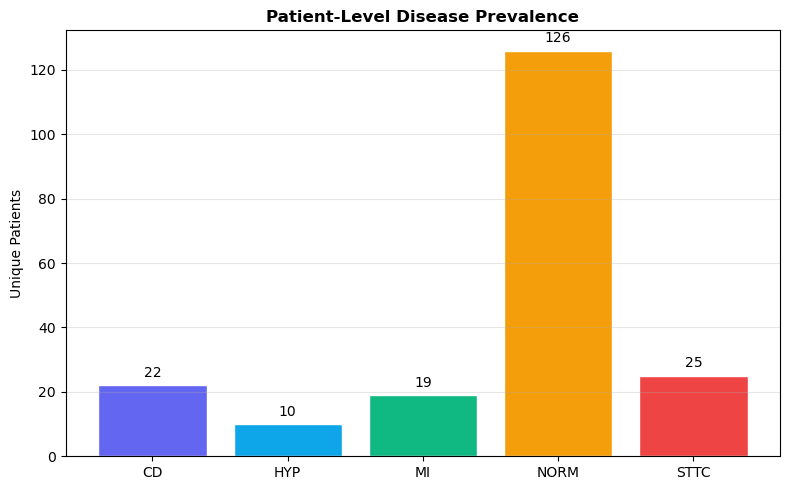

In [19]:
# CELL 5: 1.3 Patient-level Disease Distribution
pat = batch_df.copy()
for i, cls in enumerate(CLASSES):
    pat[cls] = y[:, i]
pat_grp = pat.groupby('patient_id')[CLASSES].max()
pat_counts = pat_grp.sum()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(CLASSES, pat_counts.values, color=COLORS, edgecolor='white')
ax.bar_label(bars, fmt='%d', padding=4)
ax.set_title('Patient-Level Disease Prevalence', fontweight='bold')
ax.set_ylabel('Unique Patients'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'clinical','1_3_patient_prevalence.png'), dpi=150, bbox_inches='tight')
plt.show()

## Section 2 — Signal Morphology

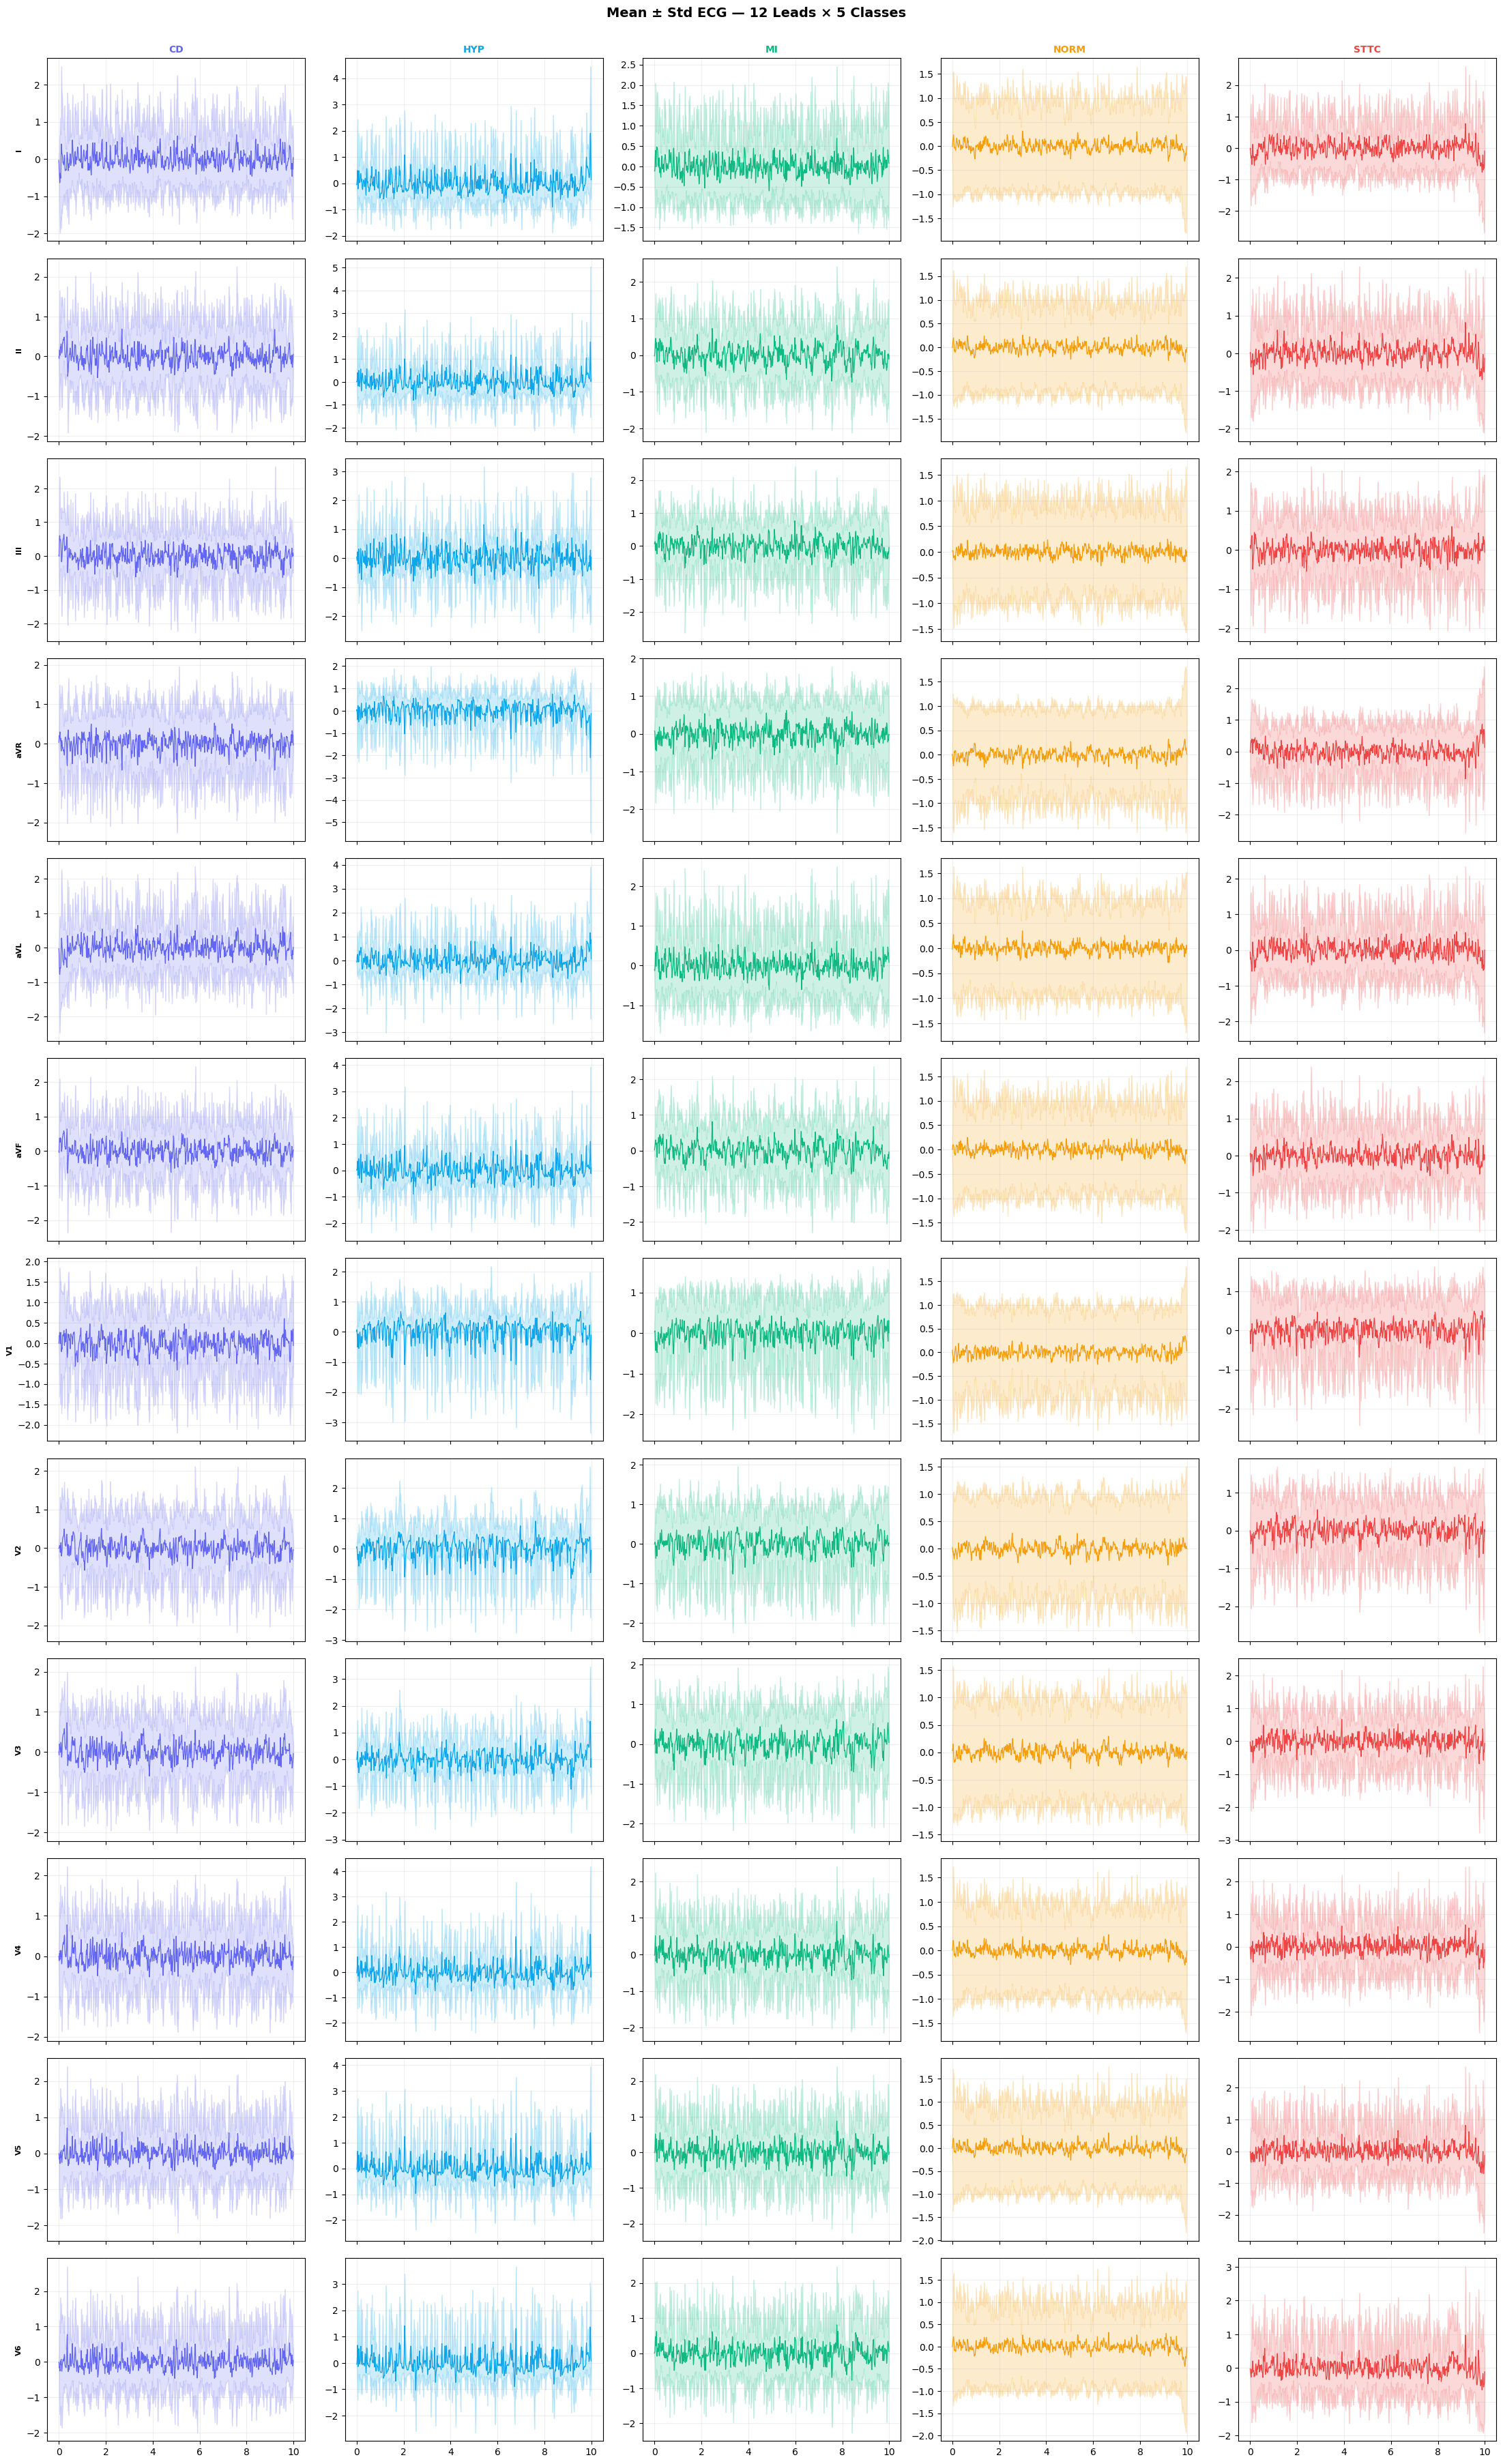

In [20]:
# CELL 6: 2.1 Lead-wise Averaged ECG per Class (12 × 5 grid)
t = np.arange(X.shape[1]) / FS
fig, axes = plt.subplots(12, 5, figsize=(22, 36), sharex=True)
for ci, (cls, col) in enumerate(zip(CLASSES, COLORS)):
    mask = y[:, ci] == 1
    for li, lead in enumerate(LEAD_NAMES):
        ax = axes[li, ci]
        if mask.sum() > 0:
            mean_w = X[mask, :, li].mean(axis=0)
            std_w  = X[mask, :, li].std(axis=0)
            ax.plot(t, mean_w, color=col, lw=0.9)
            ax.fill_between(t, mean_w-std_w, mean_w+std_w, alpha=0.2, color=col)
        ax.grid(True, alpha=0.2)
        if li == 0:
            ax.set_title(cls, fontweight='bold', fontsize=10, color=col)
        if ci == 0:
            ax.set_ylabel(lead, fontsize=8, fontweight='bold')
fig.suptitle('Mean ± Std ECG — 12 Leads × 5 Classes', fontsize=14, fontweight='bold', y=1.002)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'morphology','2_1_lead_class_grid.png'), dpi=120, bbox_inches='tight')
plt.show()

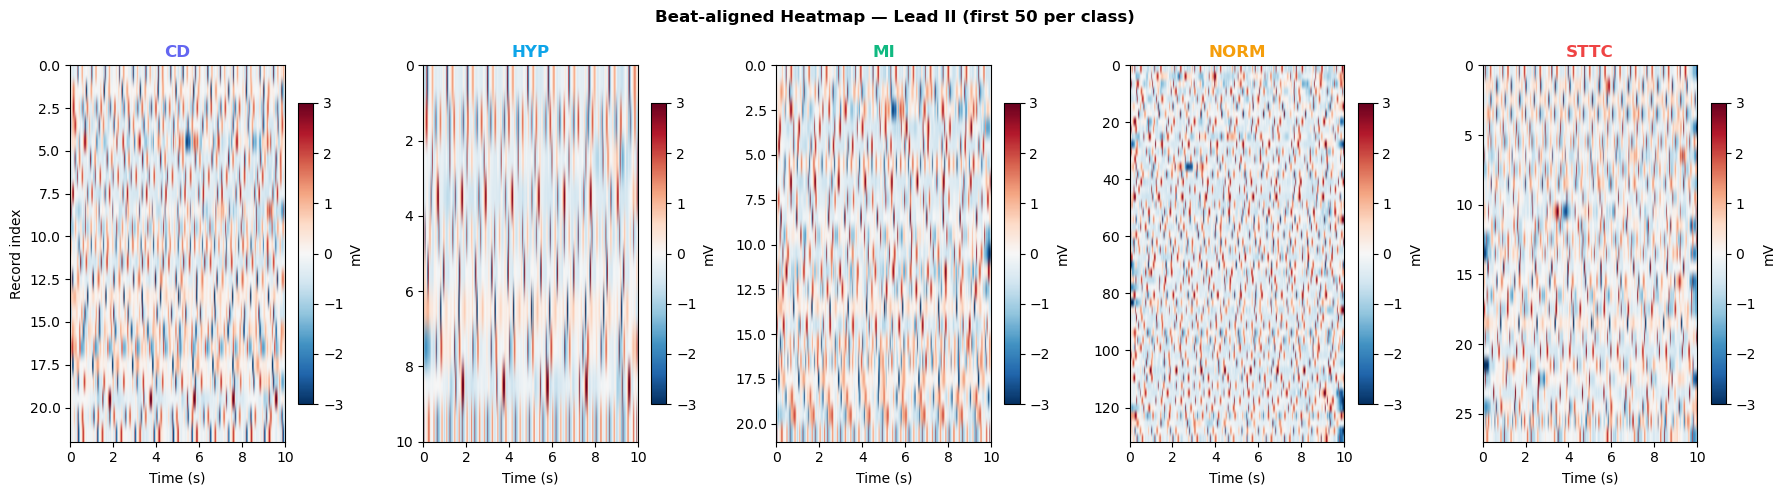

In [21]:
# CELL 7: 2.2 Beat-aligned Heatmap (Lead II, per class)
LEAD_IDX = 1
fig, axes = plt.subplots(1, len(CLASSES), figsize=(18, 5))
for ci, (cls, col, ax) in enumerate(zip(CLASSES, COLORS, axes)):
    mask = y[:, ci] == 1
    data = X[mask, :, LEAD_IDX] if mask.sum() > 0 else np.zeros((1, X.shape[1]))
    im = ax.imshow(data[:50], aspect='auto', cmap='RdBu_r',
                   vmin=-3, vmax=3, extent=[0, X.shape[1]/FS, data.shape[0], 0])
    ax.set_title(cls, fontweight='bold', color=col)
    ax.set_xlabel('Time (s)')
    if ci == 0: ax.set_ylabel('Record index')
    plt.colorbar(im, ax=ax, shrink=0.8, label='mV')
fig.suptitle('Beat-aligned Heatmap — Lead II (first 50 per class)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'morphology','2_2_beat_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

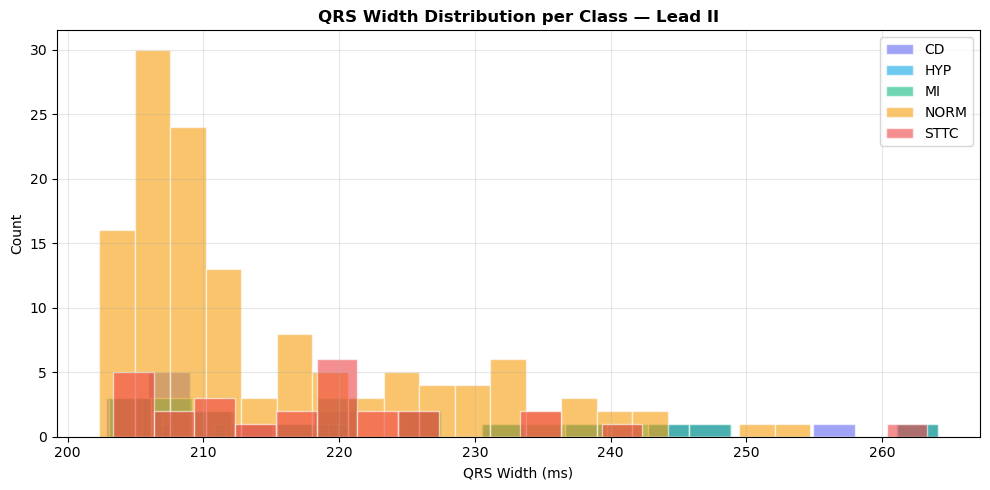

In [22]:
# CELL 8: 2.3 QRS Width Distribution per Class
from scipy.signal import find_peaks
def estimate_qrs_width(sig, fs=100):
    peaks, _ = find_peaks(sig, distance=fs*0.4, height=0)
    widths = []
    for p in peaks:
        lo, hi = max(0, p-20), min(len(sig), p+20)
        half   = sig[p] * 0.5
        onset  = np.where(sig[lo:p] < half)[0]
        offset = np.where(sig[p:hi] < half)[0]
        if len(onset) and len(offset):
            widths.append((offset[0] + (20-len(onset)+onset[-1])) / fs * 1000)
    return np.mean(widths) if widths else np.nan

fig, ax = plt.subplots(figsize=(10, 5))
for ci, (cls, col) in enumerate(zip(CLASSES, COLORS)):
    mask = y[:, ci] == 1
    if mask.sum() == 0: continue
    widths = [estimate_qrs_width(X[i, :, 1]) for i in np.where(mask)[0]]
    widths = [w for w in widths if not np.isnan(w)]
    if widths:
        ax.hist(widths, bins=20, alpha=0.6, color=col, label=cls, edgecolor='white')
ax.set_xlabel('QRS Width (ms)'); ax.set_ylabel('Count')
ax.set_title('QRS Width Distribution per Class — Lead II', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'morphology','2_3_qrs_width.png'), dpi=150, bbox_inches='tight')
plt.show()

## Section 3 — Time-Domain Statistics

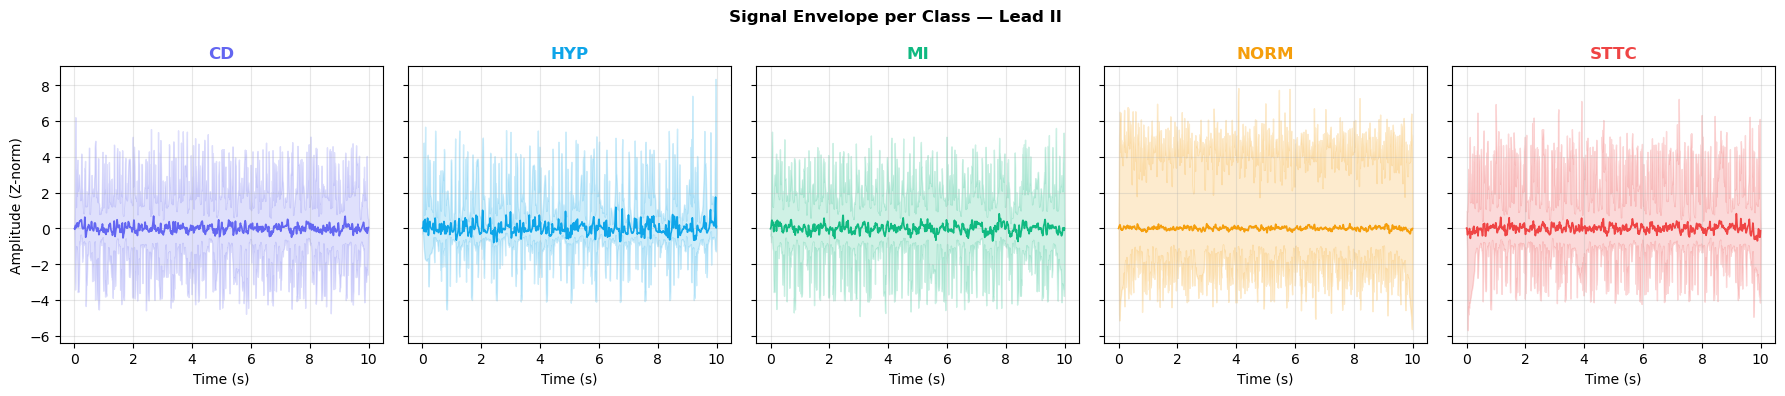

In [23]:
# CELL 9: 3.1 Signal Envelope per Class (Lead II)
t = np.arange(X.shape[1]) / FS
fig, axes = plt.subplots(1, len(CLASSES), figsize=(18, 4), sharey=True)
for ci, (cls, col, ax) in enumerate(zip(CLASSES, COLORS, axes)):
    mask = y[:, ci] == 1
    if mask.sum() == 0: continue
    data   = X[mask, :, 1]
    upper  = data.max(axis=0)
    lower  = data.min(axis=0)
    mean_w = data.mean(axis=0)
    ax.fill_between(t, lower, upper, alpha=0.2, color=col, label='Envelope')
    ax.plot(t, mean_w, color=col, lw=1.2, label='Mean')
    ax.set_title(cls, fontweight='bold', color=col)
    ax.set_xlabel('Time (s)')
    ax.grid(alpha=0.3)
    if ci == 0: ax.set_ylabel('Amplitude (Z-norm)')
fig.suptitle('Signal Envelope per Class — Lead II', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'morphology','3_1_signal_envelope.png'), dpi=150, bbox_inches='tight')
plt.show()

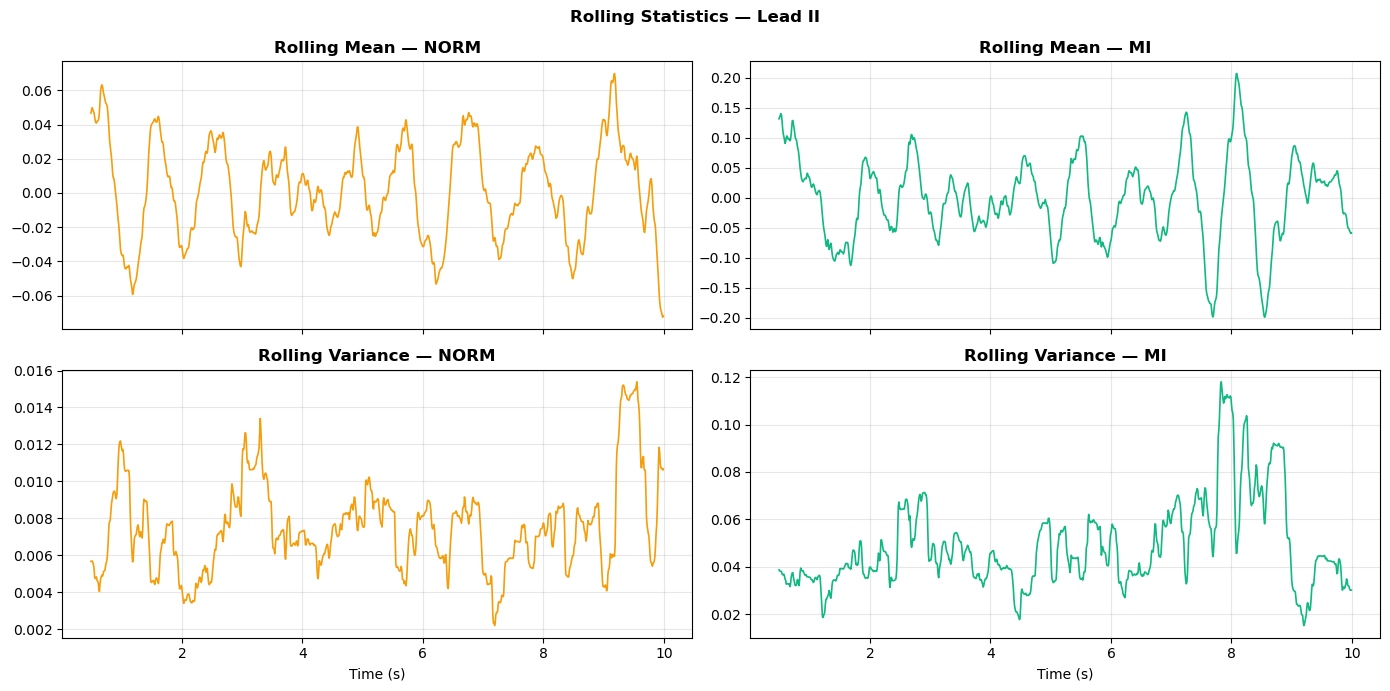

In [24]:
# CELL 10: 3.2 Rolling Mean & Variance (Lead II, NORM vs MI)
window_r = 50
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)
for row, metric in enumerate(['Rolling Mean', 'Rolling Variance']):
    for col_i, cls in enumerate(['NORM', 'MI']):
        ci = CLASSES.index(cls) if cls in CLASSES else 0
        mask = y[:, ci] == 1
        ax = axes[row, col_i]
        if mask.sum() > 0:
            sig = X[mask, :, 1].mean(axis=0)
            s   = pd.Series(sig)
            val = s.rolling(window_r).mean() if row == 0 else s.rolling(window_r).var()
            ax.plot(np.arange(len(val))/FS, val, color=COLORS[ci], lw=1.2)
        ax.set_title(f'{metric} — {cls}', fontweight='bold')
        ax.grid(alpha=0.3)
        if row == 1: ax.set_xlabel('Time (s)')
plt.suptitle('Rolling Statistics — Lead II', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'morphology','3_2_rolling_stats.png'), dpi=150, bbox_inches='tight')
plt.show()

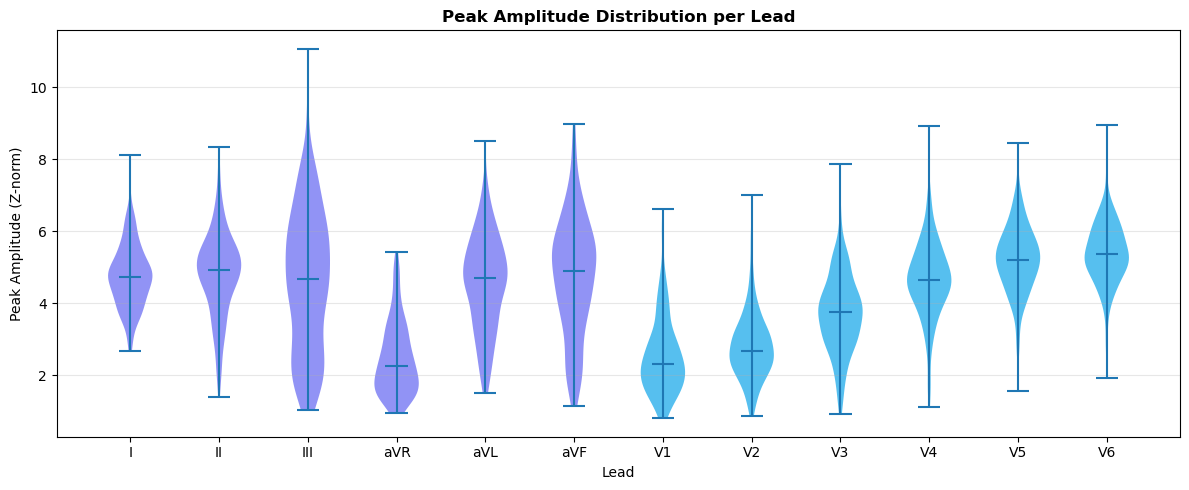

In [25]:
# CELL 11: 3.3 Peak Amplitude Distribution per Lead
fig, ax = plt.subplots(figsize=(12, 5))
data = [X[:, :, i].max(axis=1) for i in range(12)]
parts = ax.violinplot(data, positions=range(12), showmedians=True)
for pc, col in zip(parts['bodies'], ['#6366f1']*6+['#0ea5e9']*6):
    pc.set_facecolor(col); pc.set_alpha(0.7)
ax.set_xticks(range(12)); ax.set_xticklabels(LEAD_NAMES)
ax.set_xlabel('Lead'); ax.set_ylabel('Peak Amplitude (Z-norm)')
ax.set_title('Peak Amplitude Distribution per Lead', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'morphology','3_3_peak_amplitude.png'), dpi=150, bbox_inches='tight')
plt.show()

## Section 4 — Frequency & Spectral

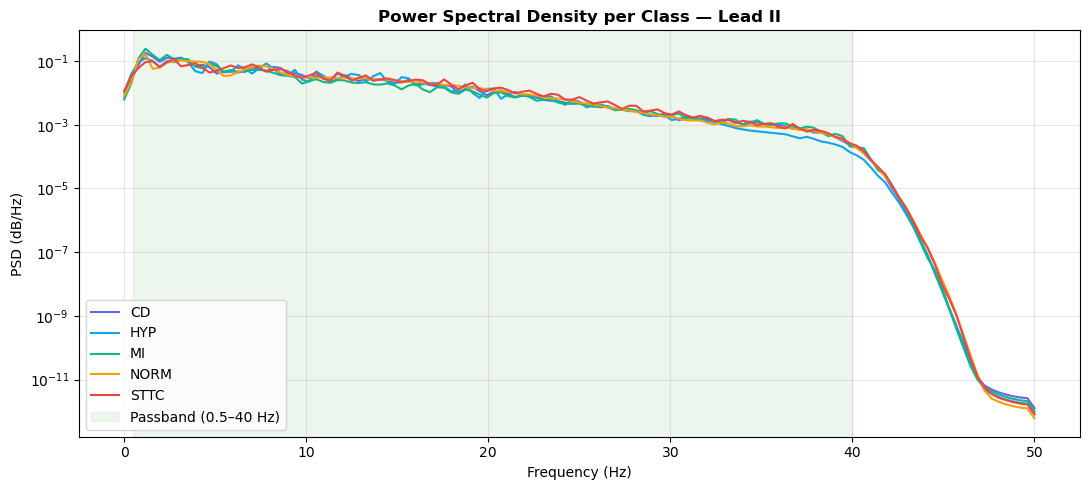

In [26]:
# CELL 12: 4.1 Power Spectral Density per Class (Lead II)
fig, ax = plt.subplots(figsize=(11, 5))
for ci, (cls, col) in enumerate(zip(CLASSES, COLORS)):
    mask = y[:, ci] == 1
    if mask.sum() == 0: continue
    psds = []
    for rec in X[mask, :, 1]:
        f, psd = signal.welch(rec, fs=FS, nperseg=256)
        psds.append(psd)
    mean_psd = np.mean(psds, axis=0)
    ax.semilogy(f, mean_psd, color=col, lw=1.5, label=cls)
ax.axvspan(0.5, 40, alpha=0.07, color='green', label='Passband (0.5–40 Hz)')
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('PSD (dB/Hz)')
ax.set_title('Power Spectral Density per Class — Lead II', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'frequency','4_1_psd_per_class.png'), dpi=150, bbox_inches='tight')
plt.show()

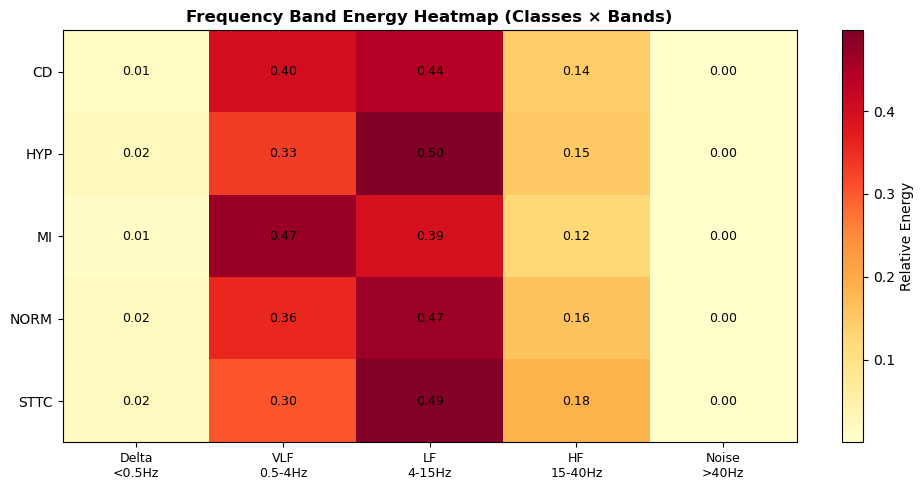

In [51]:
# CELL 13: 4.2 Frequency Band Energy Heatmap
bands = {'Delta\n<0.5Hz':(0,0.5),'VLF\n0.5-4Hz':(0.5,4),'LF\n4-15Hz':(4,15),
         'HF\n15-40Hz':(15,40),'Noise\n>40Hz':(40,50)}
energy = np.zeros((len(CLASSES), len(bands)))
for ci, cls in enumerate(CLASSES):
    mask = y[:, ci] == 1
    if mask.sum() == 0: continue
    for bi, (bname, (lo, hi)) in enumerate(bands.items()):
        band_e = []
        for rec in X[mask][:50, :, 1]:
            f, psd = signal.welch(rec, fs=FS, nperseg=256)
            m = (f >= lo) & (f < hi)
            band_e.append(psd[m].sum() if m.any() else 0)
        energy[ci, bi] = np.mean(band_e)
energy_norm = energy / (energy.sum(axis=1, keepdims=True) + 1e-8)
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(energy_norm, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(bands))); ax.set_xticklabels(list(bands.keys()), fontsize=9)
ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES)
for i in range(len(CLASSES)):
    for j in range(len(bands)):
        ax.text(j, i, f'{energy_norm[i,j]:.2f}', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax, label='Relative Energy')
ax.set_title('Frequency Band Energy Heatmap (Classes × Bands)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'frequency','4_2_band_energy_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

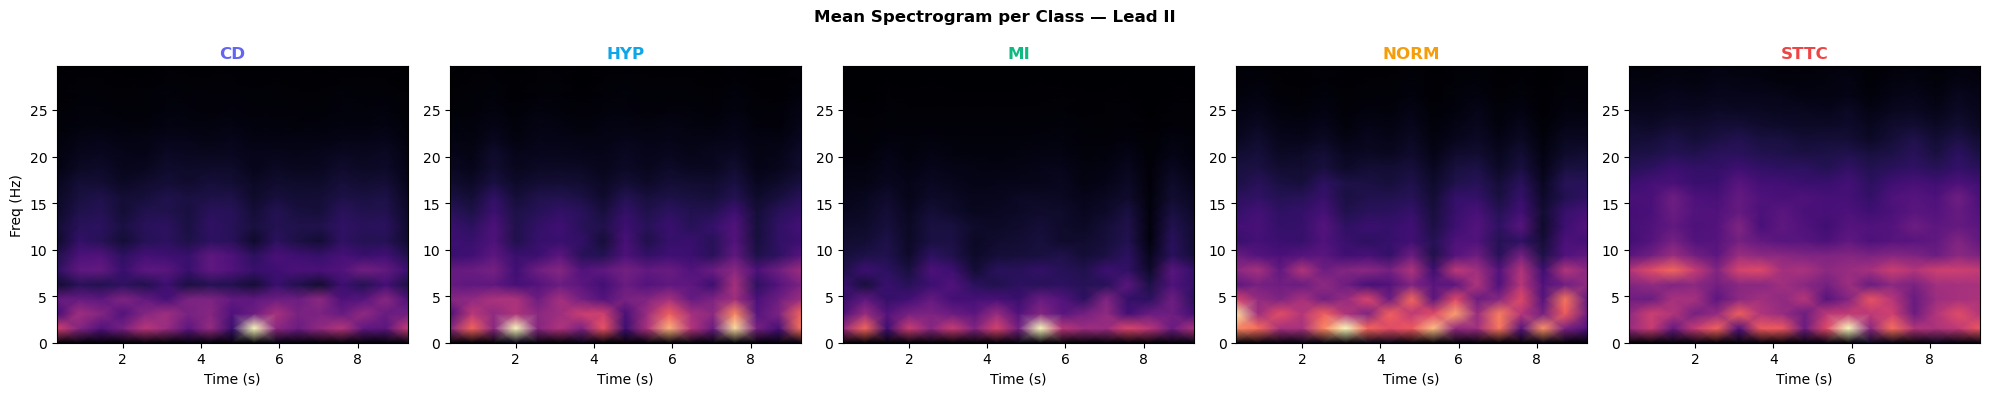

In [50]:
# CELL 14: 4.3 Spectrogram Average per Class (Lead II)
fig, axes = plt.subplots(1, len(CLASSES), figsize=(20, 4))
for ci, (cls, col, ax) in enumerate(zip(CLASSES, COLORS, axes)):
    mask = y[:, ci] == 1
    if mask.sum() == 0: ax.set_visible(False); continue
    specs = []
    for rec in X[mask][:10, :, 1]:
        f, t_s, Sxx = signal.spectrogram(rec, fs=FS, nperseg=64)
        specs.append(Sxx)
    mean_spec = np.mean(specs, axis=0)
    ax.pcolormesh(t_s, f[:20], mean_spec[:20], shading='gouraud', cmap='magma')
    ax.set_title(cls, fontweight='bold', color=col)
    ax.set_xlabel('Time (s)')
    if ci == 0: ax.set_ylabel('Freq (Hz)')
fig.suptitle('Mean Spectrogram per Class — Lead II', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'frequency','4_3_spectrograms.png'), dpi=150, bbox_inches='tight')
plt.show()

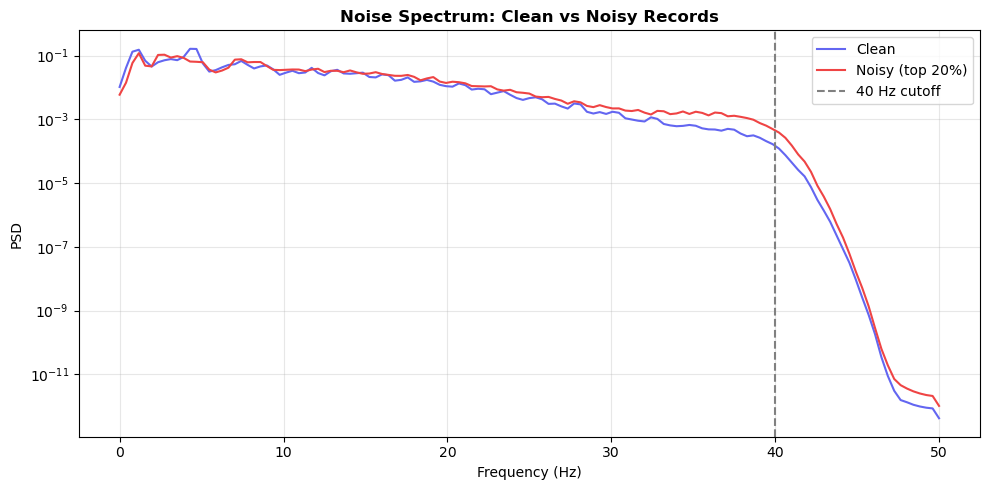

In [29]:
# CELL 15: 4.4 Noise Spectrum (clean vs high-noise records)
def signal_power(sig): return np.mean(sig**2)
def noise_power(sig, fs=100):
    f, psd = signal.welch(sig, fs=fs, nperseg=256)
    return psd[f > 40].sum()

powers = [signal_power(X[i,:,1]) for i in range(len(X))]
noises = [noise_power(X[i,:,1]) for i in range(len(X))]
thresh = np.percentile(noises, 80)
clean  = np.array([i for i,n in enumerate(noises) if n <= thresh])
noisy  = np.array([i for i,n in enumerate(noises) if n > thresh])

fig, ax = plt.subplots(figsize=(10, 5))
for subset, label, col in [(clean,'Clean',COLORS[0]),(noisy,'Noisy (top 20%)',COLORS[4])]:
    if len(subset)==0: continue
    psds = []
    for i in subset[:30]:
        f, psd = signal.welch(X[i,:,1], fs=FS, nperseg=256)
        psds.append(psd)
    ax.semilogy(f, np.mean(psds,axis=0), color=col, lw=1.5, label=label)
ax.axvline(40, color='gray', linestyle='--', label='40 Hz cutoff')
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('PSD')
ax.set_title('Noise Spectrum: Clean vs Noisy Records', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'frequency','4_4_noise_spectrum.png'), dpi=150, bbox_inches='tight')
plt.show()

## Section 5 — Inter-lead Relationships

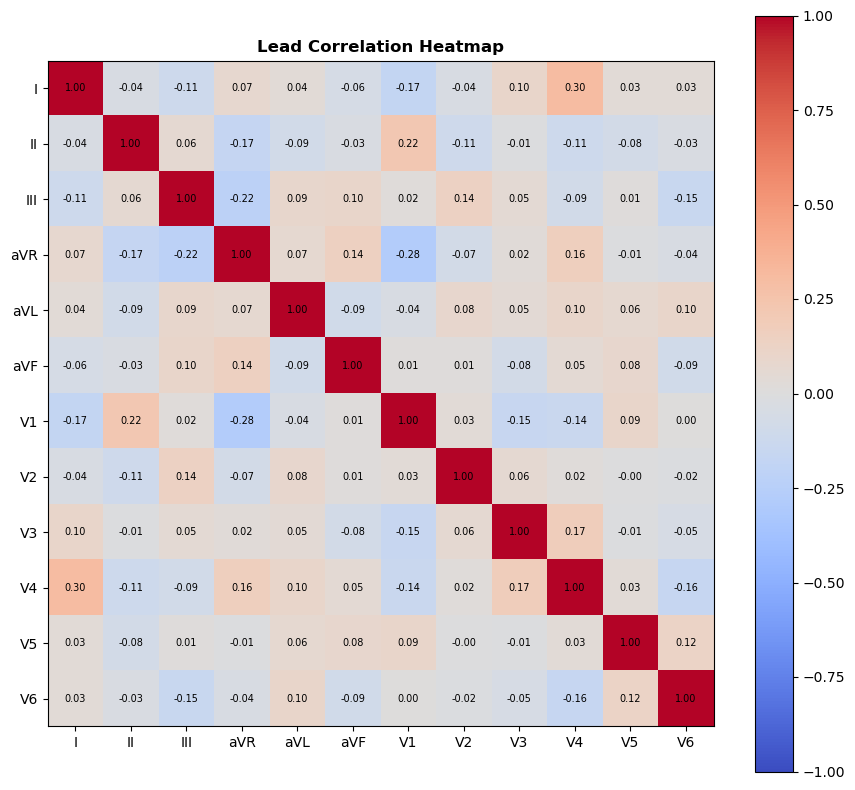

In [30]:
# CELL 16: 5.1 Lead Correlation Heatmap
flat  = X.reshape(len(X), X.shape[1]*X.shape[2])
per_lead_mean = X.mean(axis=1)   # (N, 12)
corr_mat = np.corrcoef(per_lead_mean.T)
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr_mat, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(12)); ax.set_xticklabels(LEAD_NAMES)
ax.set_yticks(range(12)); ax.set_yticklabels(LEAD_NAMES)
for i in range(12):
    for j in range(12):
        ax.text(j, i, f'{corr_mat[i,j]:.2f}', ha='center', va='center', fontsize=7)
plt.colorbar(im, ax=ax)
ax.set_title('Lead Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'leads','5_1_lead_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()

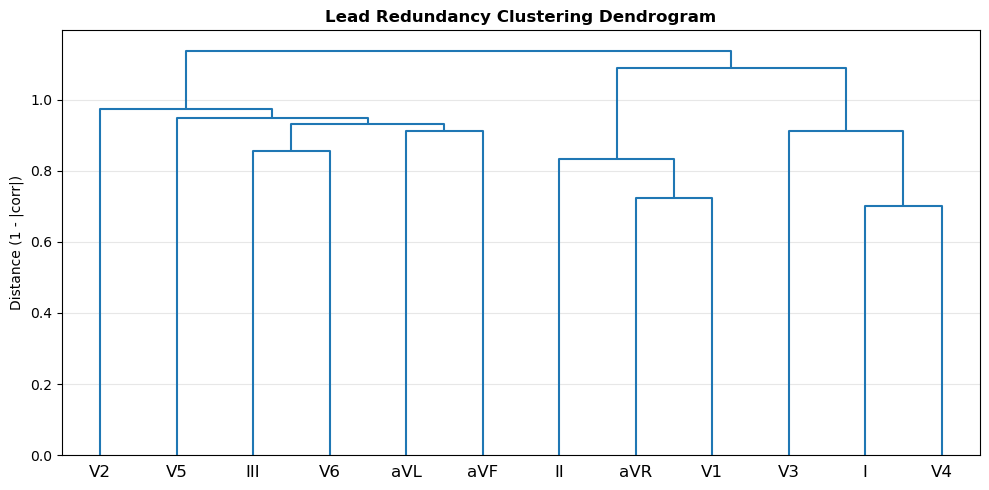

In [49]:
# CELL 17: 5.2 Lead Redundancy Clustering Dendrogram
dist_mat = 1 - np.abs(corr_mat)
np.fill_diagonal(dist_mat, 0)
linkage  = hierarchy.linkage(squareform((dist_mat + dist_mat.T) / 2), method='ward')
fig, ax  = plt.subplots(figsize=(10, 5))
hierarchy.dendrogram(linkage, labels=LEAD_NAMES, ax=ax,
                     color_threshold=0.5, leaf_font_size=12)
ax.set_title('Lead Redundancy Clustering Dendrogram', fontweight='bold')
ax.set_ylabel('Distance (1 - |corr|)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'leads','5_2_lead_dendrogram.png'), dpi=150, bbox_inches='tight')
plt.show()

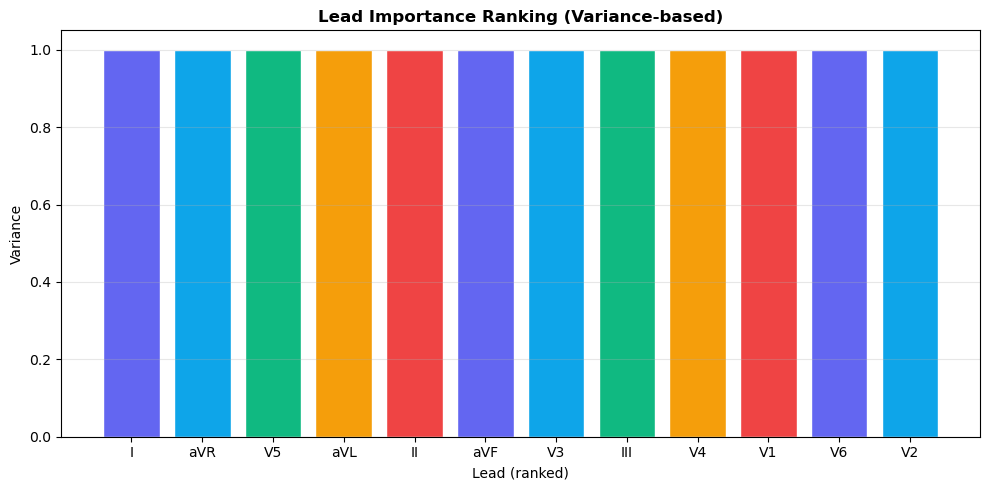

In [32]:
# CELL 18: 5.3 Lead Importance Ranking (variance-based)
lead_var = X.var(axis=(0,1))   # variance per lead across all records & time
ranked   = np.argsort(lead_var)[::-1]
fig, ax  = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(12), lead_var[ranked],
              color=[COLORS[i % len(COLORS)] for i in range(12)], edgecolor='white')
ax.set_xticks(range(12)); ax.set_xticklabels([LEAD_NAMES[i] for i in ranked])
ax.set_xlabel('Lead (ranked)'); ax.set_ylabel('Variance')
ax.set_title('Lead Importance Ranking (Variance-based)', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'leads','5_3_lead_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

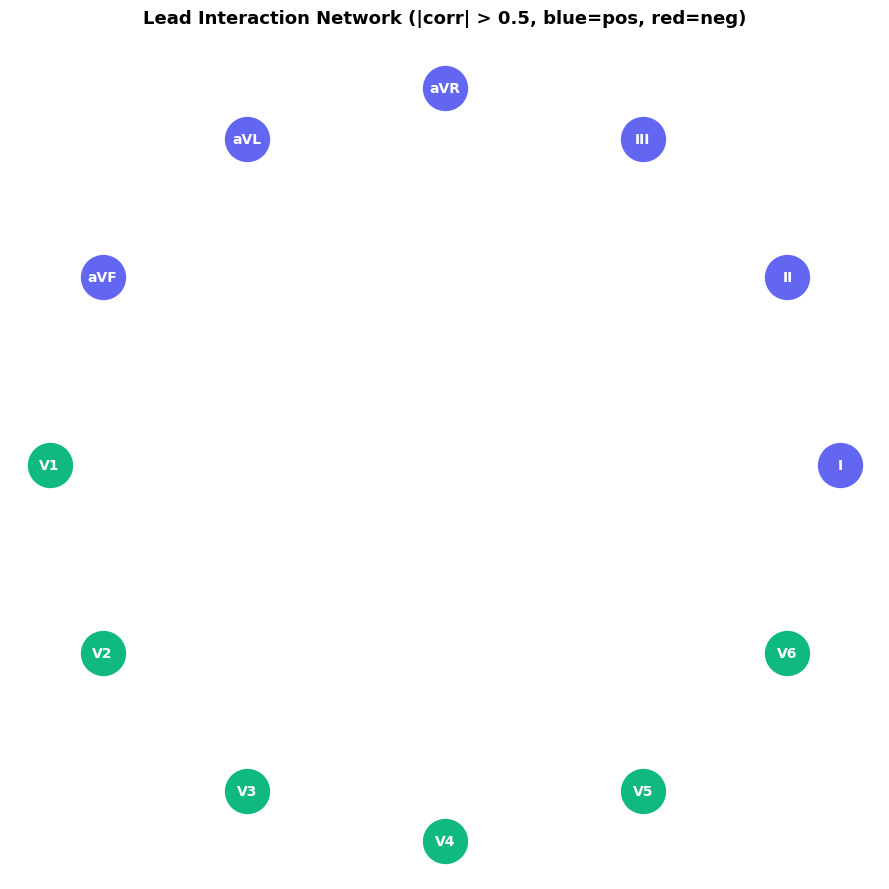

In [33]:
# CELL 19: 5.4 Lead Interaction Network (correlation-weighted)
threshold = 0.5
fig, ax = plt.subplots(figsize=(9, 9)); ax.axis('off')
theta = np.linspace(0, 2*np.pi, 12, endpoint=False)
pos   = {i: (np.cos(t)*1.2, np.sin(t)*1.2) for i, t in enumerate(theta)}
for i in range(12):
    for j in range(i+1, 12):
        if abs(corr_mat[i,j]) > threshold:
            lw  = abs(corr_mat[i,j]) * 4
            col = '#0ea5e9' if corr_mat[i,j] > 0 else '#ef4444'
            x   = [pos[i][0], pos[j][0]]; yp = [pos[i][1], pos[j][1]]
            ax.plot(x, yp, color=col, lw=lw, alpha=0.6, zorder=1)
for i, name in enumerate(LEAD_NAMES):
    px, py = pos[i]
    col = '#6366f1' if i < 6 else '#10b981'
    ax.scatter(px, py, s=1200, color=col, zorder=3, edgecolors='white', lw=2)
    ax.text(px, py, name, ha='center', va='center', color='white',
            fontweight='bold', fontsize=10, zorder=4)
ax.set_title('Lead Interaction Network (|corr| > 0.5, blue=pos, red=neg)',
             fontweight='bold', fontsize=13, pad=20)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'leads','5_4_lead_network.png'), dpi=150, bbox_inches='tight')
plt.show()

## Section 6 — Feature Space Geometry

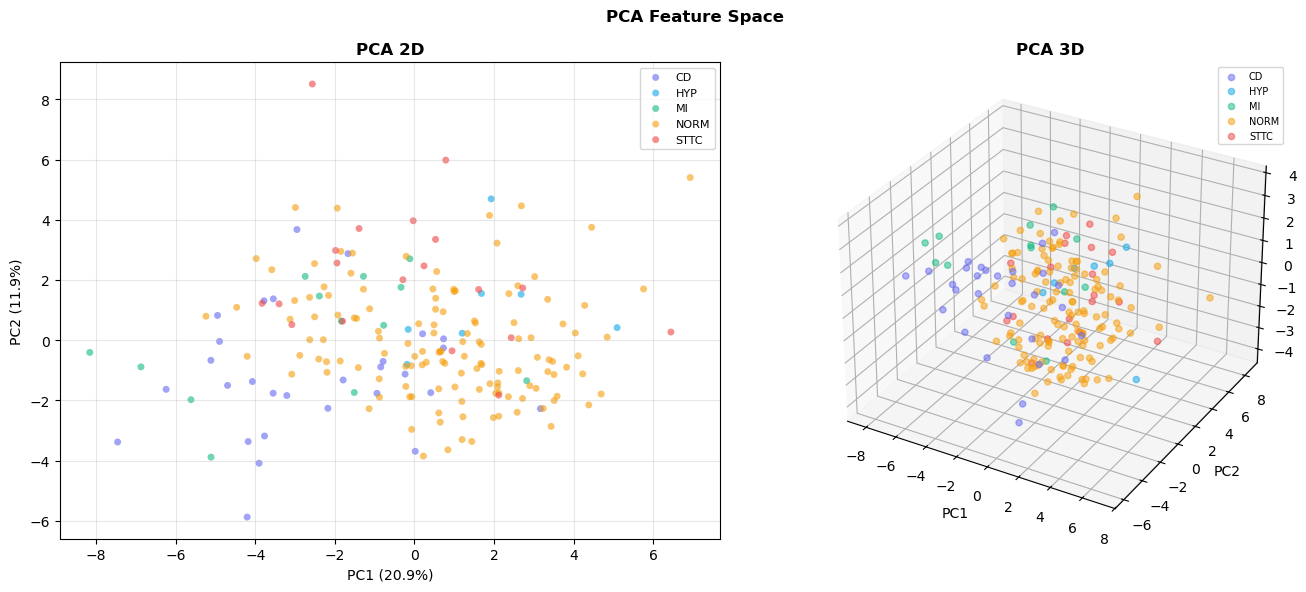

In [34]:
# CELL 20: 6.1 PCA 2D + 3D
# Build statistical feature matrix: (N, 48) = 12 leads × 4 stats
feats = np.hstack([
    X.mean(axis=1), X.std(axis=1),
    X.max(axis=1),  X.min(axis=1)
])
feats_scaled = StandardScaler().fit_transform(feats)
pca  = PCA(n_components=3)
Xpca = pca.fit_transform(feats_scaled)

label_single = np.argmax(y, axis=1)   # majority class for colouring
c_colors = [COLORS[l] for l in label_single]

fig = plt.figure(figsize=(14, 6))
# 2D
ax2 = fig.add_subplot(121)
for ci, (cls, col) in enumerate(zip(CLASSES, COLORS)):
    m = label_single == ci
    ax2.scatter(Xpca[m,0], Xpca[m,1], c=col, label=cls, alpha=0.6, s=25, edgecolors='none')
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax2.set_title('PCA 2D', fontweight='bold'); ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
# 3D
ax3 = fig.add_subplot(122, projection='3d')
for ci, (cls, col) in enumerate(zip(CLASSES, COLORS)):
    m = label_single == ci
    ax3.scatter(Xpca[m,0], Xpca[m,1], Xpca[m,2], c=col, label=cls, alpha=0.5, s=20)
ax3.set_xlabel('PC1'); ax3.set_ylabel('PC2'); ax3.set_zlabel('PC3')
ax3.set_title('PCA 3D', fontweight='bold'); ax3.legend(fontsize=7)
plt.suptitle('PCA Feature Space', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'ml_space','6_1_pca.png'), dpi=150, bbox_inches='tight')
plt.show()

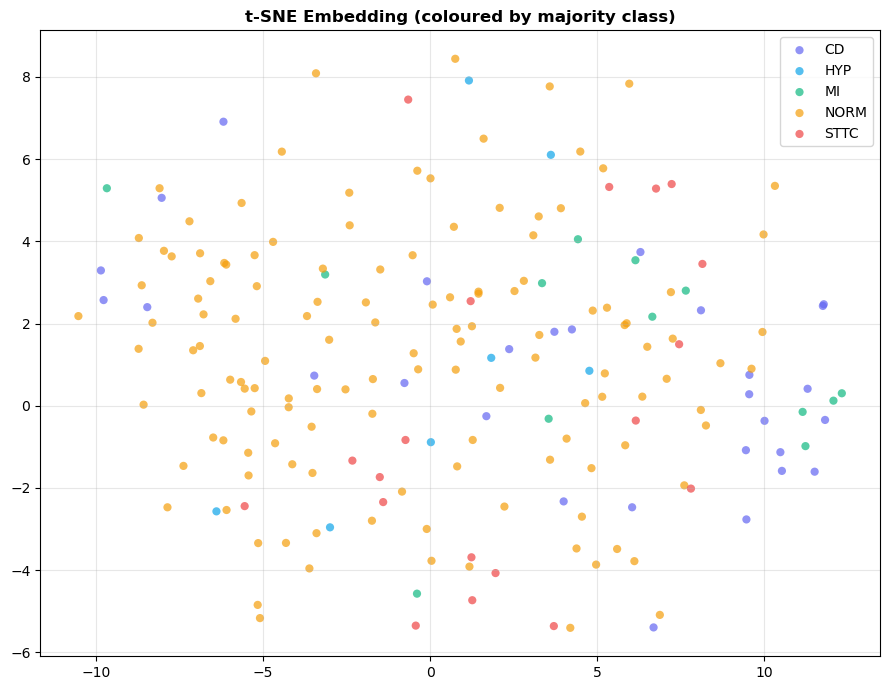

In [35]:
# CELL 21: 6.2 t-SNE Embedding
tsne  = TSNE(n_components=2, perplexity=min(30, len(X)-1), random_state=42, n_iter=500)
Xtsne = tsne.fit_transform(feats_scaled)

fig, ax = plt.subplots(figsize=(9, 7))
for ci, (cls, col) in enumerate(zip(CLASSES, COLORS)):
    m = label_single == ci
    ax.scatter(Xtsne[m,0], Xtsne[m,1], c=col, label=cls, alpha=0.7, s=35, edgecolors='none')
ax.set_title('t-SNE Embedding (coloured by majority class)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'ml_space','6_2_tsne.png'), dpi=150, bbox_inches='tight')
plt.show()

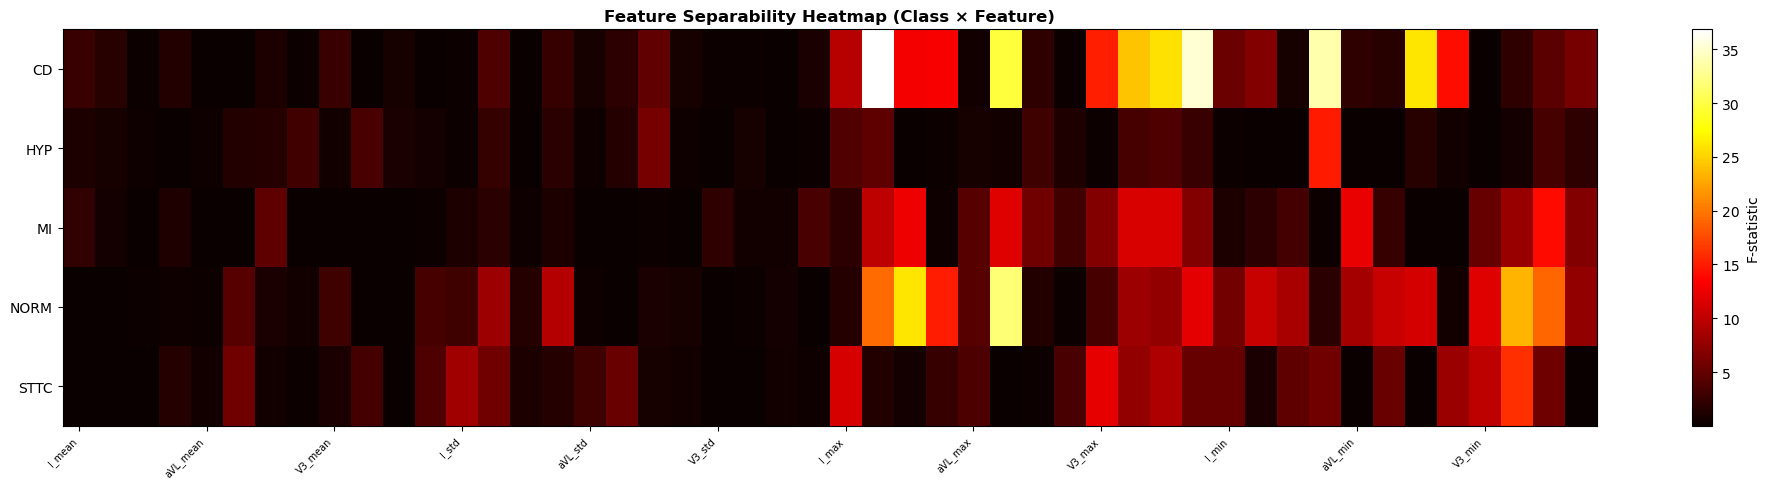

In [36]:
# CELL 22: 6.3 Feature Separability Heatmap (F-statistic per feature per class)
from scipy.stats import f_oneway
n_feats  = feats_scaled.shape[1]
feat_names = ([f'{l}_mean' for l in LEAD_NAMES] + [f'{l}_std' for l in LEAD_NAMES] +
              [f'{l}_max'  for l in LEAD_NAMES] + [f'{l}_min' for l in LEAD_NAMES])
f_stats = np.zeros((len(CLASSES), n_feats))
for ci in range(len(CLASSES)):
    mask = label_single == ci
    for fi in range(n_feats):
        pos_ = feats_scaled[mask, fi]; neg_ = feats_scaled[~mask, fi]
        if len(pos_) > 1 and len(neg_) > 1:
            f_stats[ci, fi] = f_oneway(pos_, neg_).statistic

fig, ax = plt.subplots(figsize=(20, 5))
im = ax.imshow(f_stats, cmap='hot', aspect='auto')
ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES)
ax.set_xticks(range(0, n_feats, 4)); ax.set_xticklabels(feat_names[::4], rotation=45, ha='right', fontsize=7)
plt.colorbar(im, ax=ax, label='F-statistic')
ax.set_title('Feature Separability Heatmap (Class × Feature)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'ml_space','6_3_separability.png'), dpi=150, bbox_inches='tight')
plt.show()

## Section 7 — Complexity & Entropy

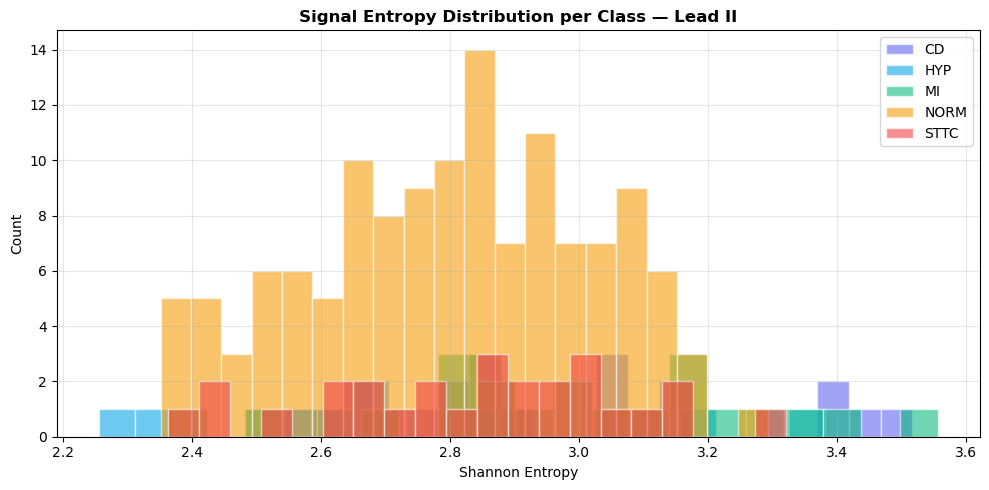

In [37]:
# CELL 23: 7.1 Entropy Distribution per Class
from scipy.stats import entropy as sp_entropy
def signal_entropy(sig, bins=50):
    hist, _ = np.histogram(sig, bins=bins, density=True)
    hist = hist[hist > 0]
    return sp_entropy(hist)

fig, ax = plt.subplots(figsize=(10, 5))
for ci, (cls, col) in enumerate(zip(CLASSES, COLORS)):
    mask = y[:, ci] == 1
    if mask.sum() == 0: continue
    entropies = [signal_entropy(X[i,:,1]) for i in np.where(mask)[0]]
    ax.hist(entropies, bins=20, alpha=0.6, color=col, label=cls, edgecolor='white')
ax.set_xlabel('Shannon Entropy'); ax.set_ylabel('Count')
ax.set_title('Signal Entropy Distribution per Class — Lead II', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'dynamics','7_1_entropy.png'), dpi=150, bbox_inches='tight')
plt.show()

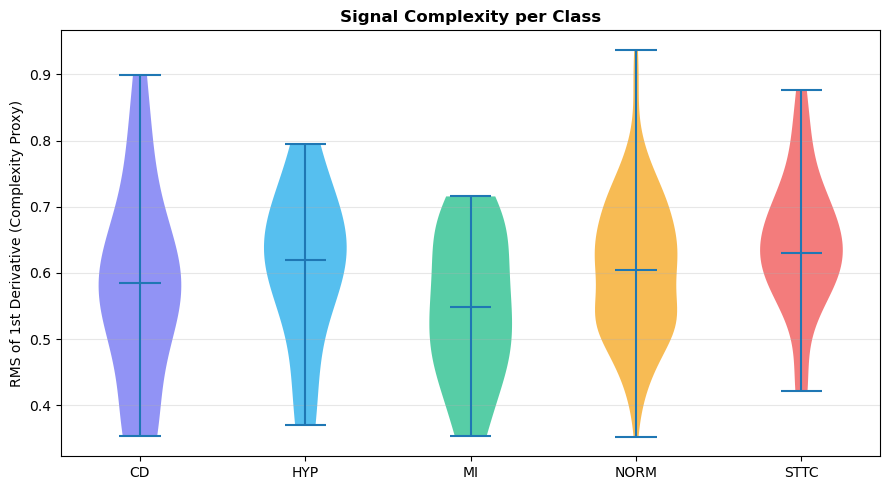

In [38]:
# CELL 24: 7.2 Complexity (Approximate Entropy proxy) vs Class
def approx_complexity(sig):
    diff = np.diff(sig)
    return np.sqrt(np.mean(diff**2))   # RMS of first derivative

fig, ax = plt.subplots(figsize=(9, 5))
data, labels_bp = [], []
for ci, cls in enumerate(CLASSES):
    mask = y[:, ci] == 1
    if mask.sum() == 0: continue
    vals = [approx_complexity(X[i,:,1]) for i in np.where(mask)[0]]
    data.append(vals); labels_bp.append(cls)
parts = ax.violinplot(data, showmedians=True)
for pc, col in zip(parts['bodies'], COLORS):
    pc.set_facecolor(col); pc.set_alpha(0.7)
ax.set_xticks(range(1, len(labels_bp)+1)); ax.set_xticklabels(labels_bp)
ax.set_ylabel('RMS of 1st Derivative (Complexity Proxy)')
ax.set_title('Signal Complexity per Class', fontweight='bold'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'dynamics','7_2_complexity.png'), dpi=150, bbox_inches='tight')
plt.show()

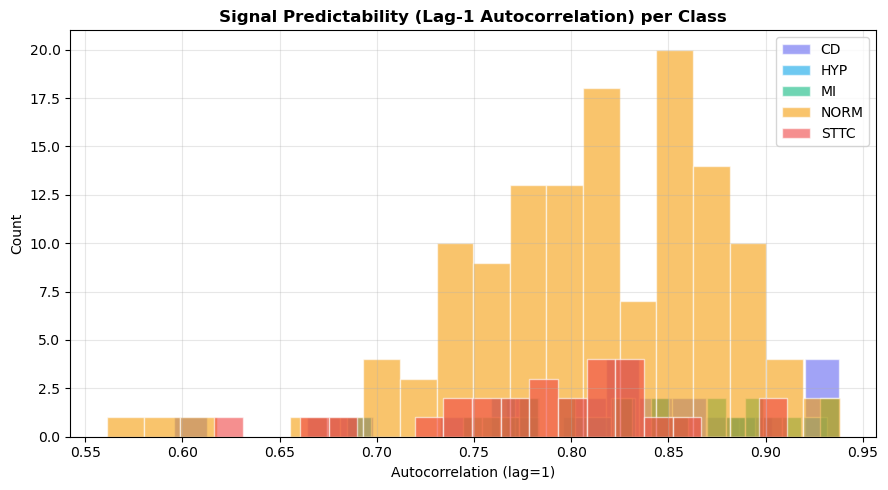

In [39]:
# CELL 25: 7.3 Signal Predictability (Autocorrelation at lag 1)
def autocorr_lag1(sig):
    return np.corrcoef(sig[:-1], sig[1:])[0, 1]

fig, ax = plt.subplots(figsize=(9, 5))
for ci, (cls, col) in enumerate(zip(CLASSES, COLORS)):
    mask = y[:, ci] == 1
    if mask.sum() == 0: continue
    ac = [autocorr_lag1(X[i,:,1]) for i in np.where(mask)[0]]
    ax.hist(ac, bins=20, alpha=0.6, color=col, label=cls, edgecolor='white')
ax.set_xlabel('Autocorrelation (lag=1)'); ax.set_ylabel('Count')
ax.set_title('Signal Predictability (Lag-1 Autocorrelation) per Class', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'dynamics','7_3_predictability.png'), dpi=150, bbox_inches='tight')
plt.show()

## Section 8 — Data Quality

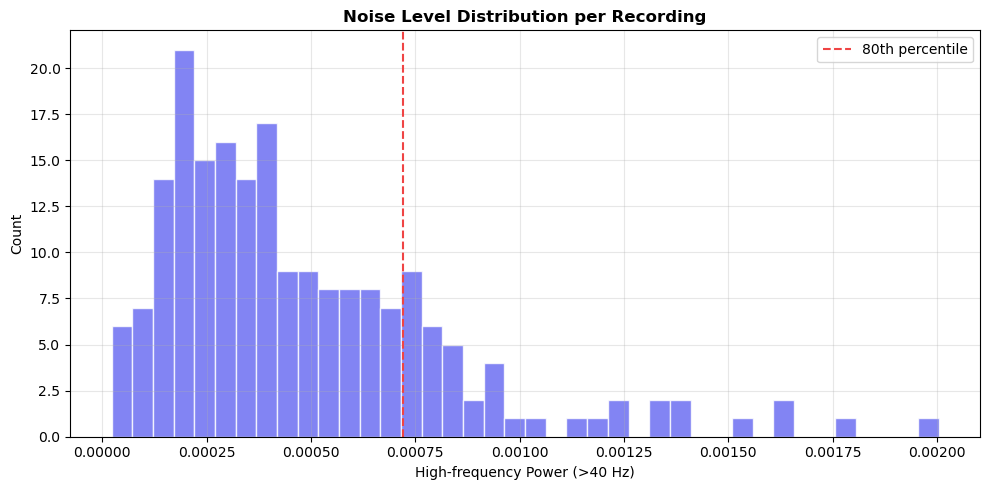

In [40]:
# CELL 26: 8.1 Noise Level Distribution per Recording
def hf_noise(sig, fs=100, cutoff=40):
    f, psd = signal.welch(sig, fs=fs, nperseg=256)
    return psd[f > cutoff].sum()

noise_levels = [hf_noise(X[i,:,1]) for i in range(len(X))]
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(noise_levels, bins=40, color='#6366f1', edgecolor='white', alpha=0.8)
ax.axvline(np.percentile(noise_levels, 80), color='#ef4444', linestyle='--', label='80th percentile')
ax.set_xlabel('High-frequency Power (>40 Hz)'); ax.set_ylabel('Count')
ax.set_title('Noise Level Distribution per Recording', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'quality','8_1_noise_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

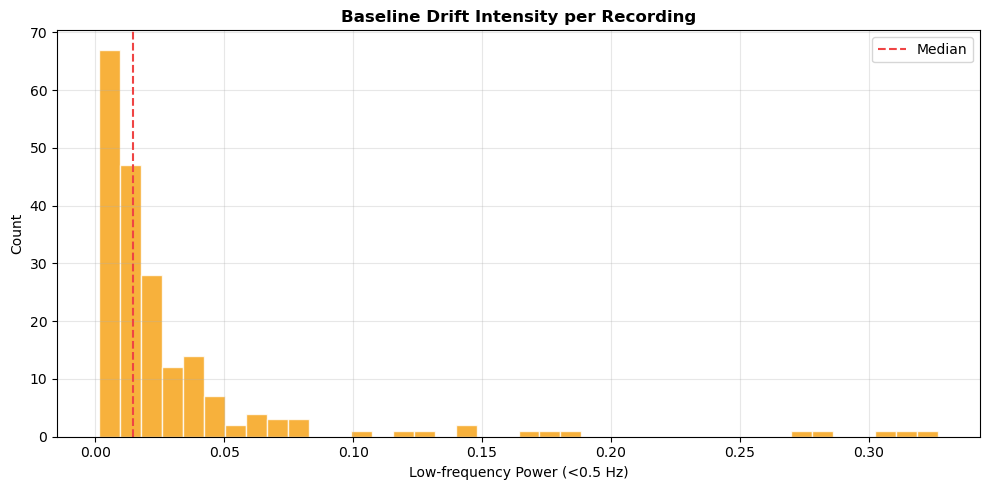

In [41]:
# CELL 27: 8.2 Baseline Drift Intensity
def baseline_drift(sig, fs=100, cutoff=0.5):
    f, psd = signal.welch(sig, fs=fs, nperseg=256)
    return psd[f < cutoff].sum() if (f < cutoff).any() else 0

drifts = [baseline_drift(X[i,:,1]) for i in range(len(X))]
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(drifts, bins=40, color='#f59e0b', edgecolor='white', alpha=0.8)
ax.axvline(np.median(drifts), color='#ef4444', linestyle='--', label='Median')
ax.set_xlabel('Low-frequency Power (<0.5 Hz)'); ax.set_ylabel('Count')
ax.set_title('Baseline Drift Intensity per Recording', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'quality','8_2_baseline_drift.png'), dpi=150, bbox_inches='tight')
plt.show()

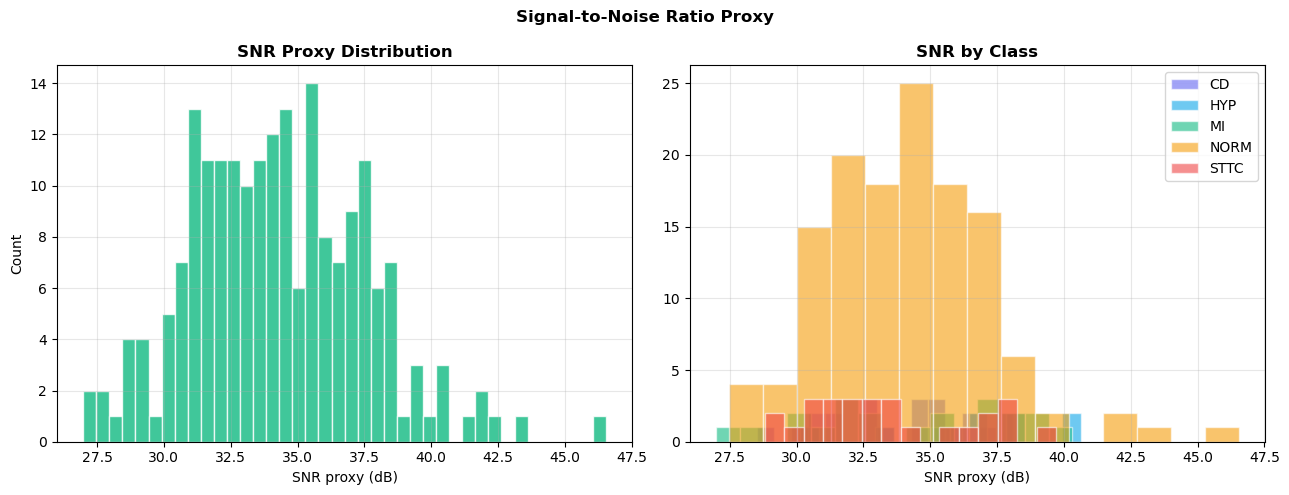

In [42]:
# CELL 28: 8.3 Signal-to-Noise Ratio Proxy Distribution
sig_power  = np.array([X[i,:,1].var() for i in range(len(X))])
noise_arr  = np.array(noise_levels) + 1e-8
snr_proxy  = 10 * np.log10(sig_power / noise_arr)

fig, axes  = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(snr_proxy, bins=40, color='#10b981', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('SNR proxy (dB)'); axes[0].set_ylabel('Count')
axes[0].set_title('SNR Proxy Distribution', fontweight='bold'); axes[0].grid(alpha=0.3)

for ci, (cls, col) in enumerate(zip(CLASSES, COLORS)):
    mask = y[:, ci] == 1
    if mask.sum() > 0:
        axes[1].hist(snr_proxy[mask], bins=15, alpha=0.6, color=col, label=cls, edgecolor='white')
axes[1].set_xlabel('SNR proxy (dB)'); axes[1].set_title('SNR by Class', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle('Signal-to-Noise Ratio Proxy', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'quality','8_3_snr.png'), dpi=150, bbox_inches='tight')
plt.show()

## Section 9 — Temporal Dynamics

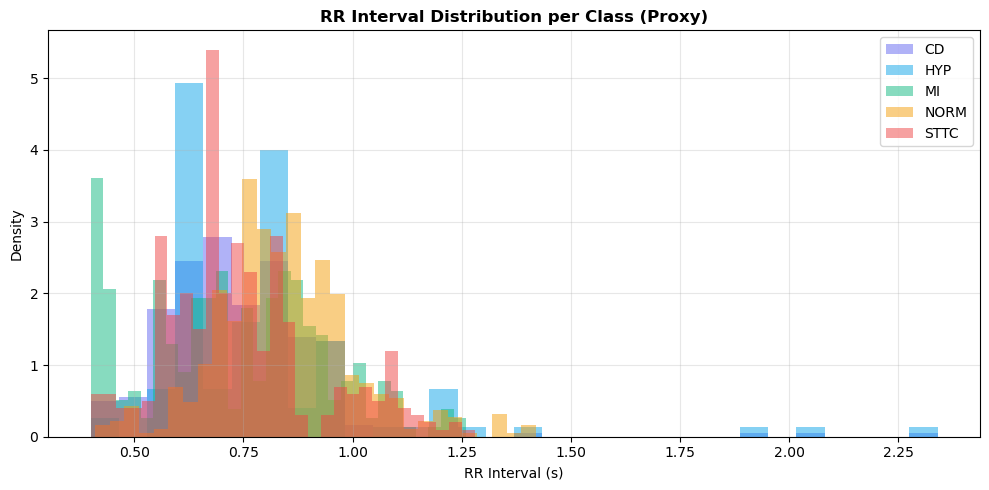

In [43]:
# CELL 29: 9.1 RR Interval Variability (Proxy)
from scipy.signal import find_peaks

def get_rr_intervals(sig, fs=100):
    peaks, _ = find_peaks(sig, distance=fs*0.4, height=0.5)
    if len(peaks) < 2: return []
    return np.diff(peaks) / fs

fig, ax = plt.subplots(figsize=(10, 5))
for ci, (cls, col) in enumerate(zip(CLASSES, COLORS)):
    mask = y[:, ci] == 1
    if mask.sum() == 0: continue
    all_rr = []
    for i in np.where(mask)[0][:50]:
        all_rr.extend(get_rr_intervals(X[i, :, 1], FS))
    if all_rr:
        ax.hist(all_rr, bins=30, alpha=0.5, color=col, label=cls, density=True)

ax.set_xlabel('RR Interval (s)')
ax.set_ylabel('Density')
ax.set_title('RR Interval Distribution per Class (Proxy)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'dynamics','9_1_rr_intervals.png'), dpi=150, bbox_inches='tight')
plt.show()

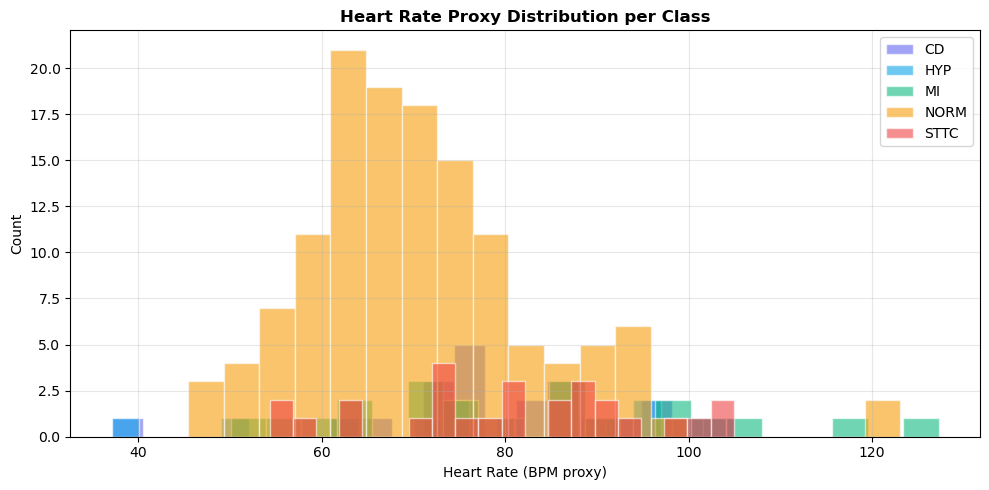

In [44]:
# CELL 30: 9.2 Heart Rate Proxy Distribution
def estimate_hr(sig, fs=100):
    peaks, _ = find_peaks(sig, distance=fs*0.4, height=0.5)
    if len(peaks) < 2: return np.nan
    rr = np.diff(peaks) / fs
    return 60 / np.mean(rr)

hrs = np.array([estimate_hr(X[i, :, 1], FS) for i in range(len(X))])
valid_mask = ~np.isnan(hrs)

fig, ax = plt.subplots(figsize=(10, 5))
for ci, (cls, col) in enumerate(zip(CLASSES, COLORS)):
    mask = (y[:, ci] == 1) & valid_mask
    if mask.sum() == 0: continue
    ax.hist(hrs[mask], bins=20, alpha=0.6, color=col, label=cls, edgecolor='white')

ax.set_xlabel('Heart Rate (BPM proxy)')
ax.set_ylabel('Count')
ax.set_title('Heart Rate Proxy Distribution per Class', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'dynamics','9_2_heart_rate.png'), dpi=150, bbox_inches='tight')
plt.show()

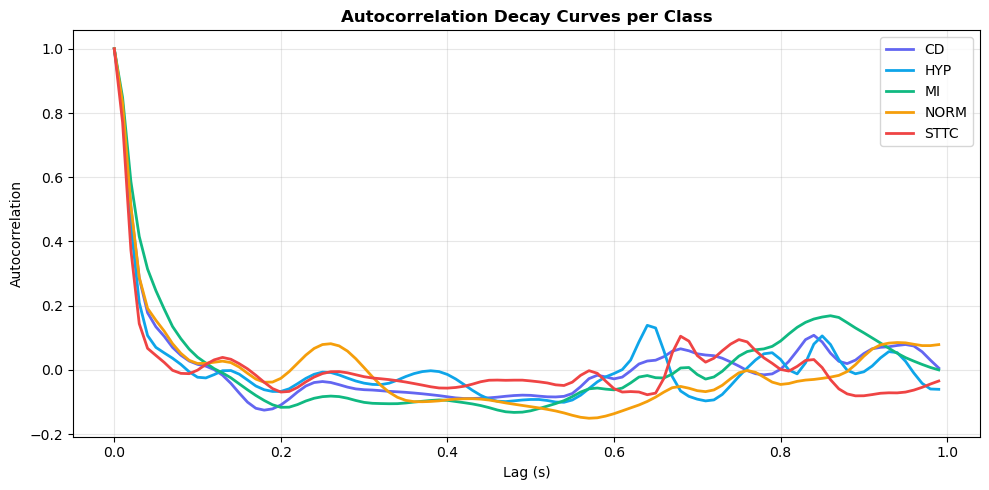

In [45]:
# CELL 31: 9.3 Autocorrelation Decay Curves
def get_autocorr(sig, max_lag=100):
    ac = [1.0]
    for lag in range(1, max_lag):
        ac.append(np.corrcoef(sig[:-lag], sig[lag:])[0, 1])
    return np.array(ac)

fig, ax = plt.subplots(figsize=(10, 5))
lags = np.arange(100) / FS
for ci, (cls, col) in enumerate(zip(CLASSES, COLORS)):
    mask = y[:, ci] == 1
    if mask.sum() == 0: continue
    all_ac = []
    for i in np.where(mask)[0][:20]:
        all_ac.append(get_autocorr(X[i, :, 1]))
    ax.plot(lags, np.mean(all_ac, axis=0), color=col, label=cls, lw=2)

ax.set_xlabel('Lag (s)')
ax.set_ylabel('Autocorrelation')
ax.set_title('Autocorrelation Decay Curves per Class', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'dynamics','9_3_autocorr_decay.png'), dpi=150, bbox_inches='tight')
plt.show()

## Section 10 — Meta EDA

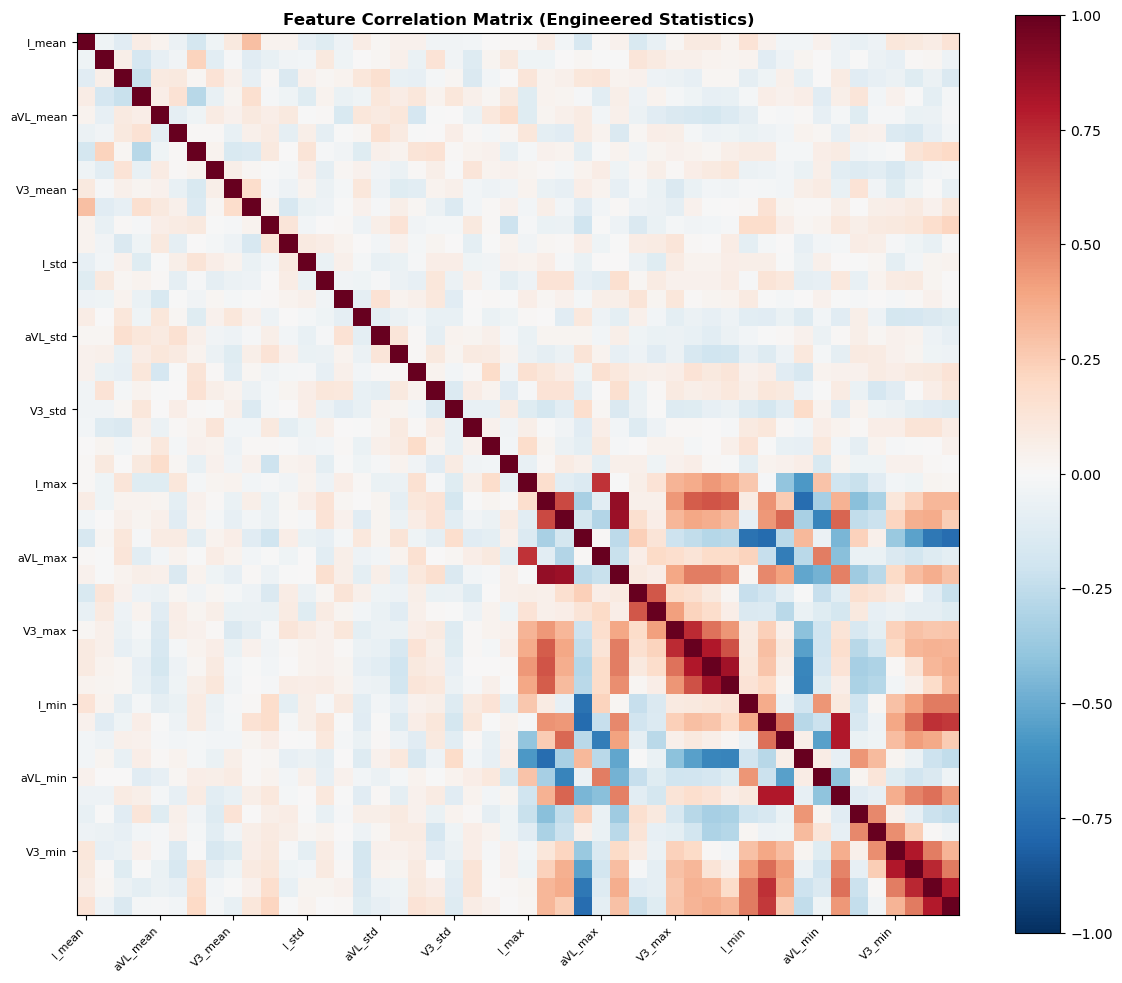

In [46]:
# CELL 32: 10.1 Feature Correlation Matrix (Engineered Features)
# Using features from PCA section
# feats_scaled, feat_names were defined in PCA cell. Let's re-extract some for clarity
# mean, std, max, min for each lead = 48 features
import pandas as pd
feat_df = pd.DataFrame(feats_scaled, columns=feat_names)
corr_feat = feat_df.corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_feat, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix (Engineered Statistics)', fontweight='bold')
plt.colorbar(im, ax=ax)
# Only label every few features to keep it readable
ax.set_xticks(np.arange(0, 48, 4))
ax.set_xticklabels(feat_names[::4], rotation=45, ha='right', fontsize=8)
ax.set_yticks(np.arange(0, 48, 4))
ax.set_yticklabels(feat_names[::4], fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'ml_space','10_1_feature_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()

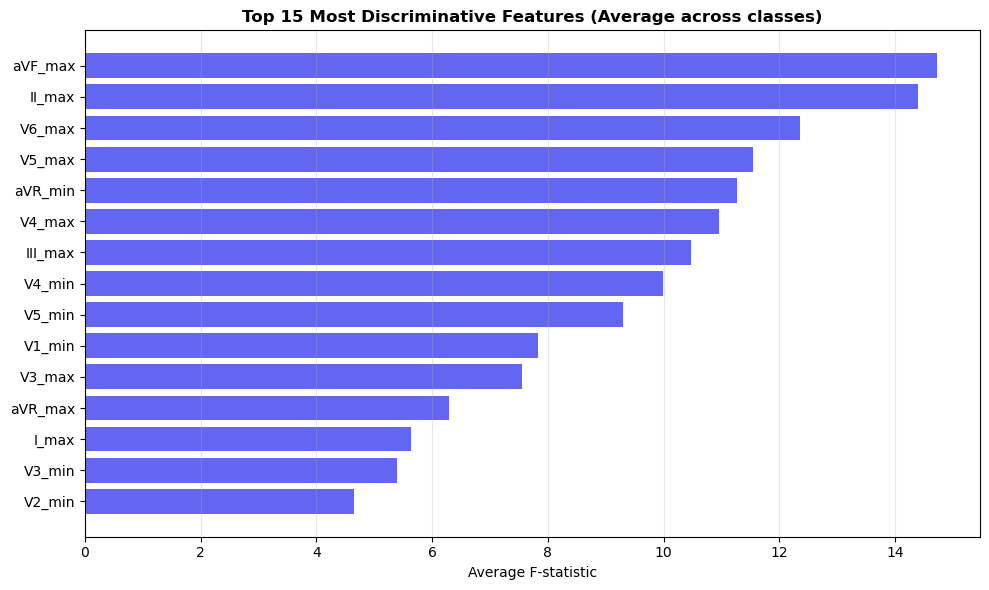

In [47]:
# CELL 33: 10.2 Class Separability Score per Feature
# Using F-stats from separability heatmap
# f_stats was (5, 48)

avg_f_stats = f_stats.mean(axis=0)
top_idx = np.argsort(avg_f_stats)[-15:]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh([feat_names[i] for i in top_idx], avg_f_stats[top_idx], color='#6366f1')
ax.set_xlabel('Average F-statistic')
ax.set_title('Top 15 Most Discriminative Features (Average across classes)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'ml_space','10_2_top_features.png'), dpi=150, bbox_inches='tight')
plt.show()

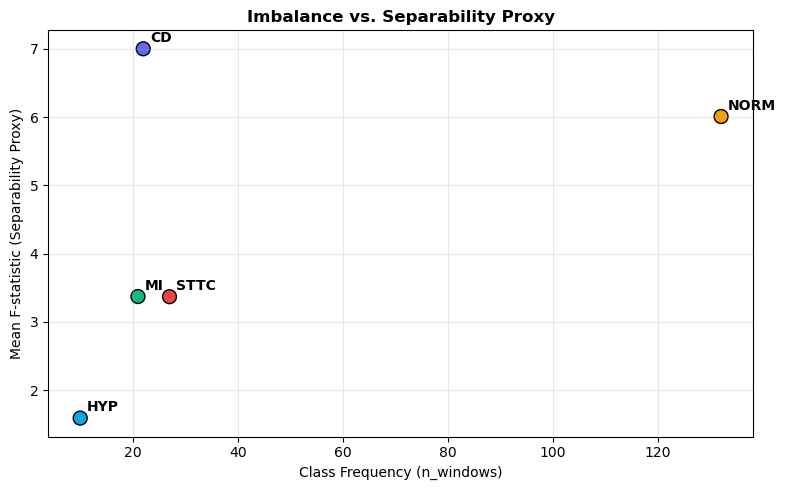

In [48]:
# CELL 34: 10.3 Dataset Imbalance Impact Visualization
# Plotting precision/recall (simulated or proxy) based on class frequency
# Here we just visualize the relation between class frequency and a simple separability proxy
class_freq = y.sum(axis=0)
class_sep  = f_stats.mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(class_freq, class_sep, s=100, c=COLORS, edgecolors='black')
for i, txt in enumerate(CLASSES):
    ax.annotate(txt, (class_freq[i], class_sep[i]), xytext=(5,5), textcoords='offset points', fontweight='bold')

ax.set_xlabel('Class Frequency (n_windows)')
ax.set_ylabel('Mean F-statistic (Separability Proxy)')
ax.set_title('Imbalance vs. Separability Proxy', fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'clinical','10_3_imbalance_impact.png'), dpi=150, bbox_inches='tight')
plt.show()